In [1]:
import pandas as pd
df = pd.read_json("../data/results/codetrans_m4_results.jsonl", lines=True)

In [2]:
import re

def extract_code(text: str) -> str:
    # Pattern explanation:
    # ```(?:\w+)? -> Matches opening backticks and optional language name (non-capturing)
    # \s* -> Matches optional whitespace/newline after the language tag
    # (.*?)        -> Captures the actual code (non-greedy)
    # \s*```       -> Matches optional whitespace and closing backticks
    pattern = r"```(?:\w+)?\s*(.*?)\s*```"
    
    # re.DOTALL allows the '.' to match newline characters
    match = re.search(pattern, text, re.DOTALL)
    
    if match:
        return match.group(1).strip()
    
    # If no code block is found, return the original text
    return text

In [3]:
from pygments.lexers import get_lexer_by_name
from pygments.token import Token

def compare_generic_tokens(code1: str, code2: str, lang:  str) -> bool:
    lexer = get_lexer_by_name(lang)

    def extract_logic(code):
        # Filter out Whitespace and Comments
        return [
            tok_value.strip() 
            for tok_type, tok_value in lexer.get_tokens(code)
            if tok_type not in Token.Text and tok_type not in Token.Comment
            and tok_value.strip() != ""
        ]

    return extract_logic(code1) == extract_logic(code2)

In [4]:
df['model_output'] = df['model_output'].apply(lambda x: extract_code(x))

In [5]:
df['match'] = df.apply(lambda row: compare_generic_tokens(row['code_raw'], row['model_output'], lang=row['lang']), axis=1)

In [6]:
# Group by model_name and aggregate the 'match' column
result = df.groupby('model_name')['match'].agg(['sum', 'mean']).reset_index()

# Rename columns for clarity
result.columns = ['model_name', 'match_count', 'percentage (%)']
result.sort_values(by="match_count", inplace=True, ascending=False)
result['percentage (%)'] = result['percentage (%)'] * 100

result

,model_name,match_count,percentage (%)
3,openrouter/openai/gpt-oss-120b,199,49.75
5,openrouter/qwen/qwen3-coder,181,45.25
4,openrouter/openai/gpt-oss-20b,160,40.00
6,openrouter/qwen/qwen3-coder-30b-a3b-instruct,135,33.75
1,openrouter/meta-llama/llama-4-maverick,127,31.75
0,openrouter/meta-llama/llama-3.3-70b-instruct,114,28.50
2,openrouter/meta-llama/llama-4-scout,59,14.75


In [7]:
# Create the pivot table with mean (accuracy)
pivot = df.pivot_table(
    index='model_name',
    columns=['lang', 'type'],  # This creates the multi-layer structure
    values='match',
    aggfunc='mean', 
    fill_value=0,
)

# Convert to percentage
pivot = pivot * 100

# Optional: Round the results for better readability
pivot = pivot.round(2)

pivot

lang                                                           c#  \
type                                         expression_statement   
model_name                                                          
openrouter/meta-llama/llama-3.3-70b-instruct                 45.0   
openrouter/meta-llama/llama-4-maverick                       48.0   
openrouter/meta-llama/llama-4-scout                          14.0   
openrouter/openai/gpt-oss-120b                               61.0   
openrouter/openai/gpt-oss-20b                                48.0   
openrouter/qwen/qwen3-coder                                  65.0   
openrouter/qwen/qwen3-coder-30b-a3b-instruct                 45.0   

lang                                                         \
type                                         string_literal   
model_name                                                    
openrouter/meta-llama/llama-3.3-70b-instruct           25.0   
openrouter/meta-llama/llama-4-maverick                 23.0   
openrouter/meta-llama/llama-4-scout                    10.0   
openrouter/openai/gpt-oss-120b                         43.0   
openrouter/openai/gpt-oss-20b                          31.0   
openrouter/qwen/qwen3-coder                            39.0   
openrouter/qwen/qwen3-coder-30b-a3b-instruct           27.0   

lang                                                         java  \
type                                         expression_statement   
model_name                                                          
openrouter/meta-llama/llama-3.3-70b-instruct                 20.0   
openrouter/meta-llama/llama-4-maverick                       20.0   
openrouter/meta-llama/llama-4-scout                          15.0   
openrouter/openai/gpt-oss-120b                               50.0   
openrouter/openai/gpt-oss-20b                                40.0   
openrouter/qwen/qwen3-coder                                  29.0   
openrouter/qwen/qwen3-coder-30b-a3b-instruct                 31.0   

lang                                                         
type                                         string_literal  
model_name                                                   
openrouter/meta-llama/llama-3.3-70b-instruct           24.0  
openrouter/meta-llama/llama-4-maverick                 36.0  
openrouter/meta-llama/llama-4-scout                    20.0  
openrouter/openai/gpt-oss-120b                         45.0  
openrouter/openai/gpt-oss-20b                          41.0  
openrouter/qwen/qwen3-coder                            48.0  
openrouter/qwen/qwen3-coder-30b-a3b-instruct           32.0

In [21]:
def show_samples(n=1, match=True):
    """
    Show n random samples.
    - match=True: print model_output with masked part highlighted in GREEN
    - match=False: replace <MASKED> in code_masked with masked highlighted in RED
    """
    GREEN = "\033[92m"
    RED = "\033[91m"
    RESET = "\033[0m"

    samples = df[(df['match'] == match) & (df['type']=="expression_statement")].sample(n)

    for i, (_, sample) in enumerate(samples.iterrows(), start=1):
        masked = sample['masked']

        if match:
            text = sample['model_output']
            if isinstance(masked, str) and masked in text:
                text = text.replace(
                    masked, f"{GREEN}{masked}{RESET}"
                )
        else:
            text = sample['code_masked']
            if isinstance(masked, str):
                text = text.replace(
                    "<MASKED>", f"{RED}{masked}{RESET}"
                )

        print(f"--- Sample {i} ---")
        print(text)


In [22]:
print("Not matching examples:")
show_samples(5, False)

Not matching examples:
--- Sample 1 ---
public CellGeneralFormatter() {this(LocaleUtil.getUserLocale());}
--- Sample 2 ---
public DescribeOrganizationConfigurationResult describeOrganizationConfiguration(DescribeOrganizationConfigurationRequest request) {request = beforeClientExecution(request);return executeDescribeOrganizationConfiguration(request);}
--- Sample 3 ---
public CreateNetworkAclEntryResult createNetworkAclEntry(CreateNetworkAclEntryRequest request) {request = beforeClientExecution(request);return executeCreateNetworkAclEntry(request);}
--- Sample 4 ---
public AuthorizeDBSecurityGroupIngressRequest(string dbSecurityGroupName){_dbSecurityGroupName = dbSecurityGroupName;}
--- Sample 5 ---
public EscherDgRecord createDgRecord() {EscherDgRecord dg = new EscherDgRecord();dg.setRecordId( EscherDgRecord.RECORD_ID );short dgId = findNewDrawingGroupId();dg.setOptions( (short) ( dgId << 4 ) );dg.setNumShapes( 0 );dg.setLastMSOSPID( -1 );drawingGroups.add(dg);dgg.addCluster( dgId, 0 

In [29]:
print("Matching examples:")
show_samples(5, True)

Matching examples:
--- Sample 1 ---
public static short[] copyOfRange(short[] original, int start, int end) {
    if (start > end) {
        throw new IllegalArgumentException();
    }
    int originalLength = original.length;
    if (start < 0 || start > originalLength) {
        throw new ArrayIndexOutOfBoundsException();
    }
    int resultLength = end - start;
    int copyLength = Math.min(resultLength, originalLength - start);
    short[] result = new short[resultLength];
    System.arraycopy(original, start, result, 0, copyLength);
    return result;
}
--- Sample 2 ---
public Allocator(int blockSize) {this.blockSize = blockSize;}
--- Sample 3 ---
public virtual ListEntitiesDetectionJobsResponse ListEntitiesDetectionJobs(ListEntitiesDetectionJobsRequest request)
{
    var options = new InvokeOptions();
    options.RequestMarshaller = ListEntitiesDetectionJobsRequestMarshaller.Instance;
    options.ResponseUnmarshaller = ListEntitiesDetectionJobsResponseUnmarshaller.Instance;
    

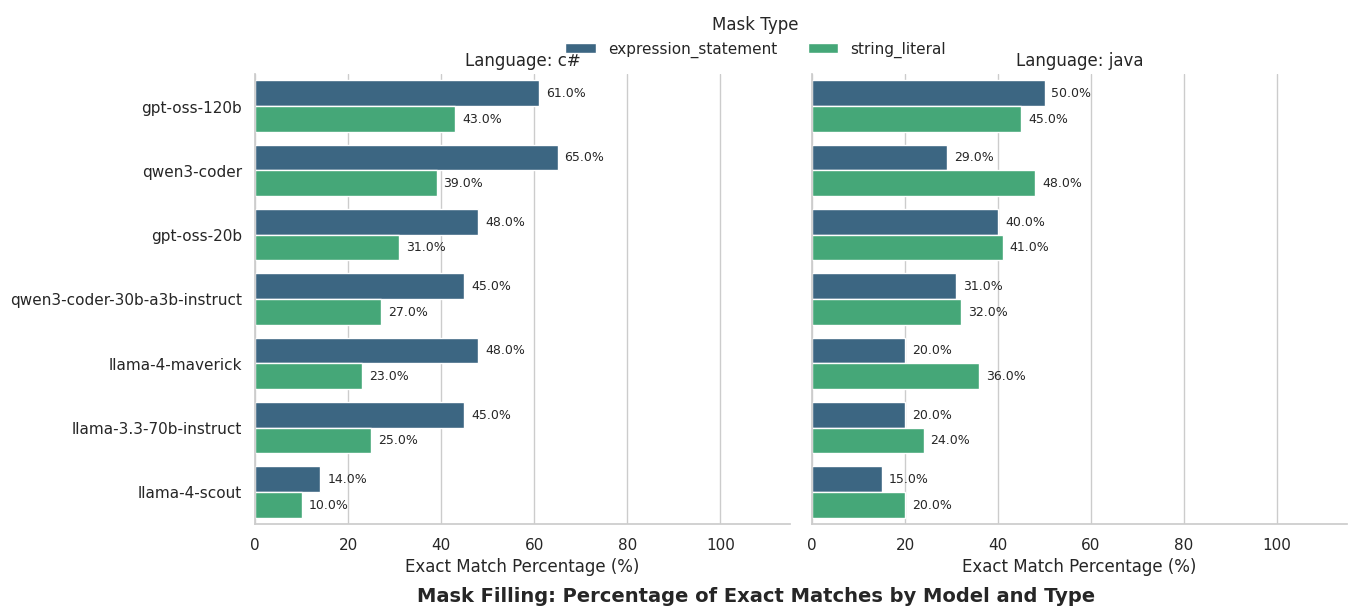

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the model name
df['model_display_name'] = df['model_name'].str.split('/').str[-1]

# 2. Group and calculate percentages
plot_df = df.groupby(['model_display_name', 'lang', 'type'])['match'].mean().reset_index()
plot_df['percentage'] = plot_df['match'] * 100

# 3. Calculate sorting order (highest overall average first)
model_order = (
    plot_df.groupby('model_display_name')['percentage']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Initialize the plot with the calculated order
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="percentage",
    y="model_display_name",
    order=model_order,  # Applies the sorted order here
    hue="type",
    col="lang",
    palette="viridis",
    height=6,
    aspect=1.2
)

# 5. Refine Axes and Labels
g.set_axis_labels("Exact Match Percentage (%)", "")
g.set_titles("Language: {col_name}")

# Add percentage text to bars
for ax in g.axes.flat:
    ax.set_xlim(0, 115)
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{width:.1f}%', 
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', 
                        xytext=(5, 0), textcoords='offset points', fontsize=9)

# 6. Move Legend to the Top
handles, labels = g._legend.legend_handles, [t.get_text() for t in g._legend.get_texts()]
g._legend.remove() 

g.fig.legend(
    handles=handles, 
    labels=labels, 
    title='Mask Type', 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=len(labels), 
    frameon=False
)

# 7. Move Title to the Bottom
plt.subplots_adjust(top=0.9, bottom=0.15) 
g.figure.text(0.5, 0.02, 'Mask Filling: Percentage of Exact Matches by Model and Type', 
           ha='center', fontsize=14, fontweight='bold')

plt.show()